In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

from core.rings_plot import plot_phase_with_insets, build_optimized_ring_graph, draw_weighted_network_on_ax, plot_dissipation_N2, plot_fig2b_N2, plot_Figure3, add_insets_to_Figure3, plot_Figure4, plot_curves_fixed_betas, plot_curves_fixed_gammas, add_network_inset_xy, save_phase_data
from core.rings_calc import get_capacities_all_branches, compute_ring_second_moment_matrix, expected_dissipation_ring, k_symmetric, compute_asymmetric_case_from_sigma, build_weighted_ring_graph_from_kvec, kvec_N2_mu0_broken, gamma_c_vs_N, get_Figure10_data

# Figure 2

Symmetry breaking in an elementary ring network with $N = 2, \mu = 0, \beta = 1.0, \kappa = 1$.

(a): The expected dissipation $\bar D(k_1)$ for two values of the scaling exponent $\gamma = \{0.8,  1.2\}$.
- For $\gamma<1$ there are two minima on the boundary of the domain corresponding to symmetry-broken states with $k^*_1 = k^*_2=0$ and $k_3=k_4= 2^{-1/\gamma} \kappa$ or $k^*_3 = k^*_4=0$ and $k_1=k_2= 2^{-1/\gamma} \kappa$.
- For $\gamma>1$ there is a single local minimum corresponding to a symmetric state $k^*_1 = k^*_2= k^*_3 = k^*_4= \kappa \cdot 4^{-1/\gamma} \kappa$. 

(b): The optimal edge capacities as a function of the scaling exponent $\gamma$. The insets show the optimal network structure for $\gamma=0.7$ and $\gamma=1.2$.

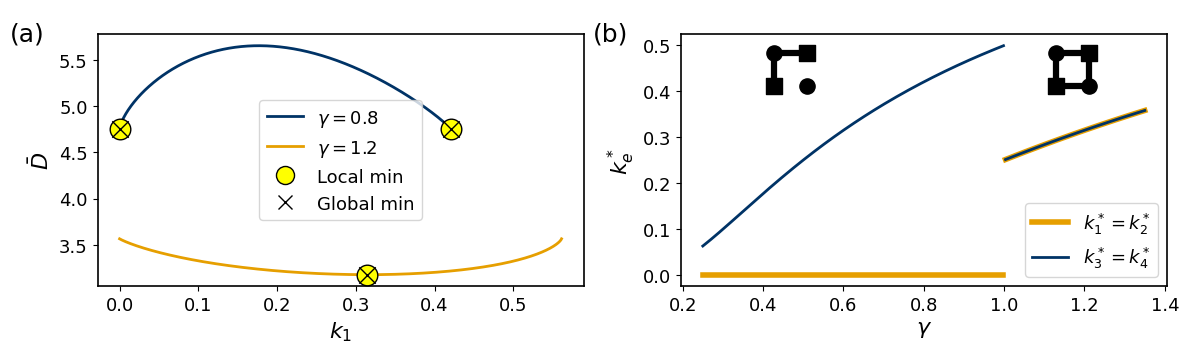

In [2]:
# Define plot characteristics

legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='yellow', markeredgecolor='black', markersize=13, label='Local min'),
    Line2D([0], [0], marker='x', linestyle='None', lw = 3.0, color='black', markersize=10, label='Global min')
]

mpl.rcParams.update({"font.size": 14, "axes.labelsize": 16, "axes.titlesize": 16, "legend.fontsize": 13, "xtick.labelsize": 13, "ytick.labelsize": 13})
mpl.rcParams["axes.linewidth"] = 1.2
mpl.rcParams["lines.linewidth"] = 2

# Define system parameters

mu = 0.0
beta = 1.0
kappa = 1.0
gammas_a = [0.8, 1.2]
gammas_b = np.linspace(0.25, 1.35, 220)

# Figure 
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 3.8))

# Subplot (a)
plot_dissipation_N2(gammas_a, mu=0.0, beta=1.0, kappa=1.0, ax=ax_left, legend_elements=legend_elements)
ax_left.text(-0.18, 1.05, "(a)", transform=ax_left.transAxes, fontsize=18, va="top")

# Subplot (b)
plot_fig2b_N2(gammas_b, kappa=1.0, ax=ax_right)
ax_right.text(-0.18, 1.05, "(b)", transform=ax_right.transAxes, fontsize=18, va="top")

# Inset positions
ax_inset1 = ax_right.inset_axes([0.12, 0.75, 0.28, 0.35])
ax_inset2 = ax_right.inset_axes([0.70, 0.75, 0.28, 0.35])

# Representative networks for selected gammas
gamma_left = 0.7
gamma_right = 1.2
k_left = kvec_N2_mu0_broken(gamma_left, kappa=kappa, which="left")
k_right = k_symmetric(2, gamma_right, kappa=kappa)

G_left = build_weighted_ring_graph_from_kvec(k_left)
G_right = build_weighted_ring_graph_from_kvec(k_right)

pos_square_4 = {
    0: (0, 0),
    1: (-0.15, 0),
    2: (-0.15, -0.15),
    3: (0, -0.15),
}

draw_weighted_network_on_ax(G_left, ax_inset1, pos_square_4, color="black")
draw_weighted_network_on_ax(G_right, ax_inset2, pos_square_4, color="black")

fig.tight_layout()
#plt.savefig("Figure2.pdf", bbox_inches="tight")
plt.show()

# Figure 3

Symmetry breaking via an exchange of local and global minima in an elementary ring network with $N=3$ and $\mu=0$. We show the expected dissipation $\bar D(k_1,k_3)$ for three values of the scaling exponent $\gamma$.

(a) For $\gamma=0.55$ there are three minima on the boundary of the domain corresponding to symmetry-broken states. The symmetric state is a local minimum but has a higher value of $\bar D$ than the symmetry-broken state.

(b) For $\gamma=0.6$ the minima exchange roles: The symmetric state is the global minimum while the symmetry-broken states are local minima with a higher value of the dissipation. No local minimum is lost during the transition to symmetry breaking.

(c) For $\gamma=1.05$, $\bar D$ is convex and there is a single minimum corresponding to the symmetric state.

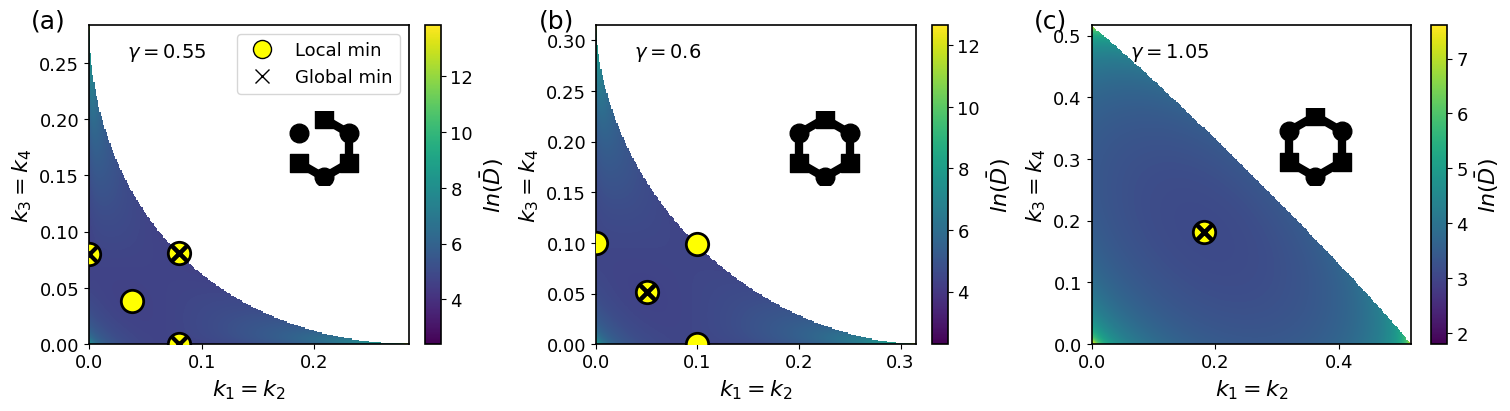

In [3]:
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='yellow', markeredgecolor='black', markersize=13, label='Local min'),
    Line2D([0], [0], marker='x', linestyle='None', lw = 3.0, color='black', markersize=10, label='Global min')
]

mu = 0.0
beta = 1.0
kappa = 1.0

gammas = [0.55, 0.60, 1.05]
labels = ["(a)", "(b)", "(c)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

for i, (ax, g) in enumerate(zip(axes, gammas)):
    plot_Figure3(g, mu=mu, beta=beta, kappa=kappa, grid=260, ax=ax)
    add_insets_to_Figure3(ax, g, kappa=kappa)

    ax.text(-0.18, 1.05, labels[i], transform=ax.transAxes, fontsize=18, va="top")
    if i == 0:
        ax.legend(handles=legend_elements, loc="upper right")

#plt.savefig("Fig3_with_insets.pdf", bbox_inches="tight")
plt.show()

# Figure 4

The optimal edge capacities as a function of the scaling exponent $\gamma$ in an elementary ring network with $N=3$ and $\mu =0$. The solid lines correspond to global minima and the dashed lines correspond to local minima.

The symmetry-breaking transition takes place at a critical value $\gamma_c=\ln(3/2)/\ln(2) \approx 0.585$ where the roles of the local and global minima exchange (dotted line).

The local minima undergo a bifurcation and vanish at $\gamma_b=1$ (dash-dotted line).

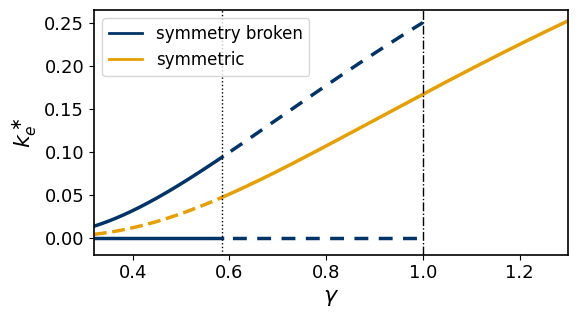

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.4))
plot_Figure4(ax=ax, kappa=1.0, gamma_min=0.32, gamma_max=1.3)
plt.tight_layout()
#plt.savefig("Figure4.pdf", bbox_inches="tight")
plt.show()

# Figure 5

Phase diagram of the optimal network structure for the ring model class for $\mu=1$.

The insets visualize the optimal network structure in the corresponding regions.

We plot the smallest edge capacity in the optimal network $\min_{e \in \mathcal{E}} k_e^*$ as a function of the fluctuation strength $\beta$ and the scaling exponent $\gamma$ for (a) $N=2$, (b) $N=3$, and (c) $N=4$.

Strong symmetry breaking is indicated by $\min_{e \in \mathcal{E}} k_e^* = 0$, i.e.,~one edge is missing in the optimal networks. The stability boundaries of the symmetry broken state are denoted in white dash-dotted lines. 

In [19]:
N = 2
mu = 1.0

gamma_values = np.linspace(0.3, 1.1, 500)
beta_values  = np.linspace(0.0, 4.0, 500)
capacity_values, branch_labels = get_capacities_all_branches(N, mu, beta_values, gamma_values)

save_phase_data(N, capacity_values, branch_labels, beta_values, gamma_values)

# To later load:
#df_cap = pd.read_csv(f"capacity_values_N{N}.csv", index_col=0)
#df_branch = pd.read_csv(f"branch_labels_N{N}.csv", index_col=0)

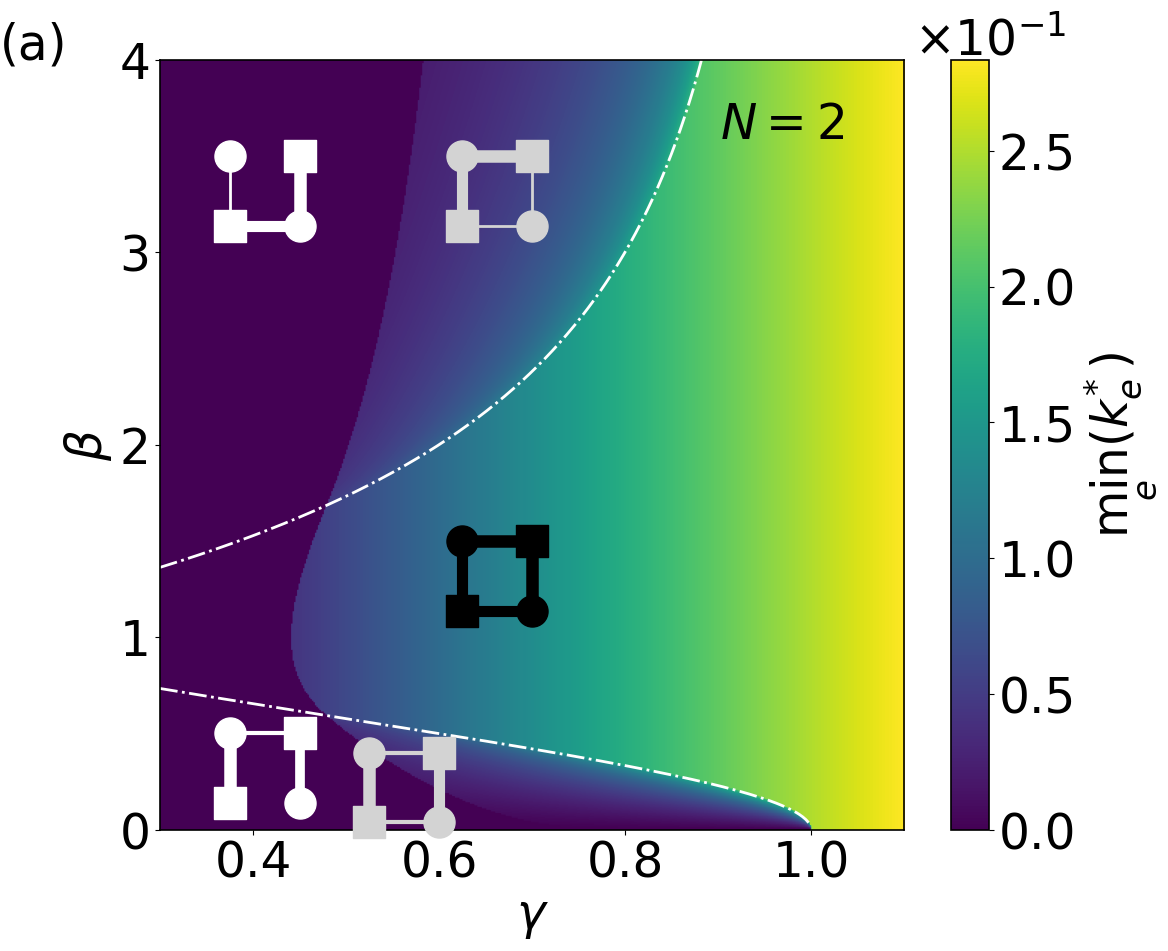

In [20]:
#gamma, beta, color
insets = [(0.45, 0.5, "white"), (0.45, 3.5, "white"), (0.7, 1.5, "black"), (0.7, 3.5, "lightgray"), (0.6, 0.4, "lightgray")]

fig, ax = plot_phase_with_insets(N, mu, gamma_values, beta_values, capacity_values, insets, "(a)", save_final_fig=False)

with np.errstate(invalid='ignore'): # ignore output about invalid value encountered in sqrt due to gamma > 1
    beta_line_lower = np.sqrt((1-gamma_values)/(1+gamma_values))
    beta_line_upper = np.sqrt((1+gamma_values)/(1-gamma_values))

ax.plot(gamma_values, beta_line_lower, color="white", linewidth=2, linestyle = "dashdot")
ax.plot(gamma_values, beta_line_upper, color="white", linewidth=2, linestyle = "dashdot")
ax.set_xlim([min(gamma_values), max(gamma_values)])
ax.set_ylim([min(beta_values), max(beta_values)])
plt.savefig("Fig5_a.pdf", bbox_inches="tight")
plt.show()

In [21]:
N = 3
mu = 1.0

gamma_values = np.linspace(0.25, 0.5, 500)
beta_values  = np.linspace(0.0, 2.0, 500)
capacity_values, branch_labels = get_capacities_all_branches(N, mu, beta_values, gamma_values)

save_phase_data(N, capacity_values, branch_labels, beta_values, gamma_values)

# To later load:
#capacity_values = pd.read_csv(f"capacity_values_N{N}.csv", index_col=0).to_numpy(dtype=float)
#branch_labels = pd.read_csv(f"branch_labels_N{N}.csv", index_col=0).to_numpy(dtype=object)

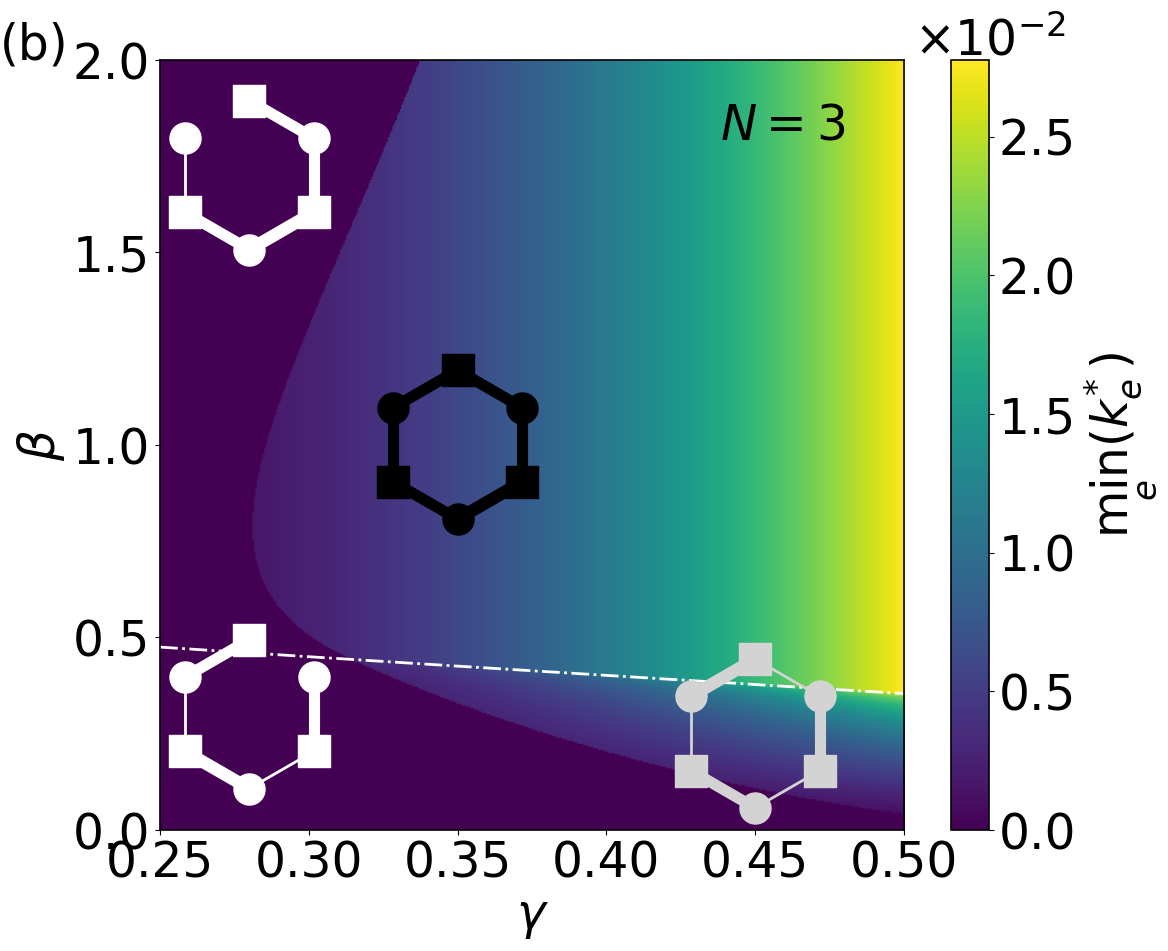

In [22]:
#gamma, beta, color
insets = [(0.28, 0.3, "white"), (0.28, 1.7, "white"), (0.35, 1.0, "black"), (0.45, 0.25, "lightgray")]

fig, ax = plot_phase_with_insets(N, mu, gamma_values, beta_values, capacity_values, insets, "(b)", save_final_fig=False)

factor = np.sqrt(3*mu*mu/(N*N-1))
beta_line_lower = factor*np.sqrt((1-gamma_values)/(1+gamma_values))

ax.plot(gamma_values, beta_line_lower, color="white", linewidth=2, linestyle="dashdot")
ax.set_xlim([min(gamma_values), max(gamma_values)])
ax.set_ylim([min(beta_values), max(beta_values)])
plt.savefig("Fig5_b.pdf", bbox_inches="tight")
plt.show()

In [23]:
N = 4
mu = 1.0
gamma_values = np.linspace(0.18, 0.3, 500)
beta_values  = np.linspace(0.0, 2.0, 500)
capacity_values, branch_labels = get_capacities_all_branches(N, mu, beta_values, gamma_values)

save_phase_data(N, capacity_values, branch_labels, beta_values, gamma_values)

# To later load:
#capacity_values = pd.read_csv(f"capacity_values_N{N}.csv", index_col=0).to_numpy(dtype=float)
#branch_labels = pd.read_csv(f"branch_labels_N{N}.csv", index_col=0).to_numpy(dtype=object)

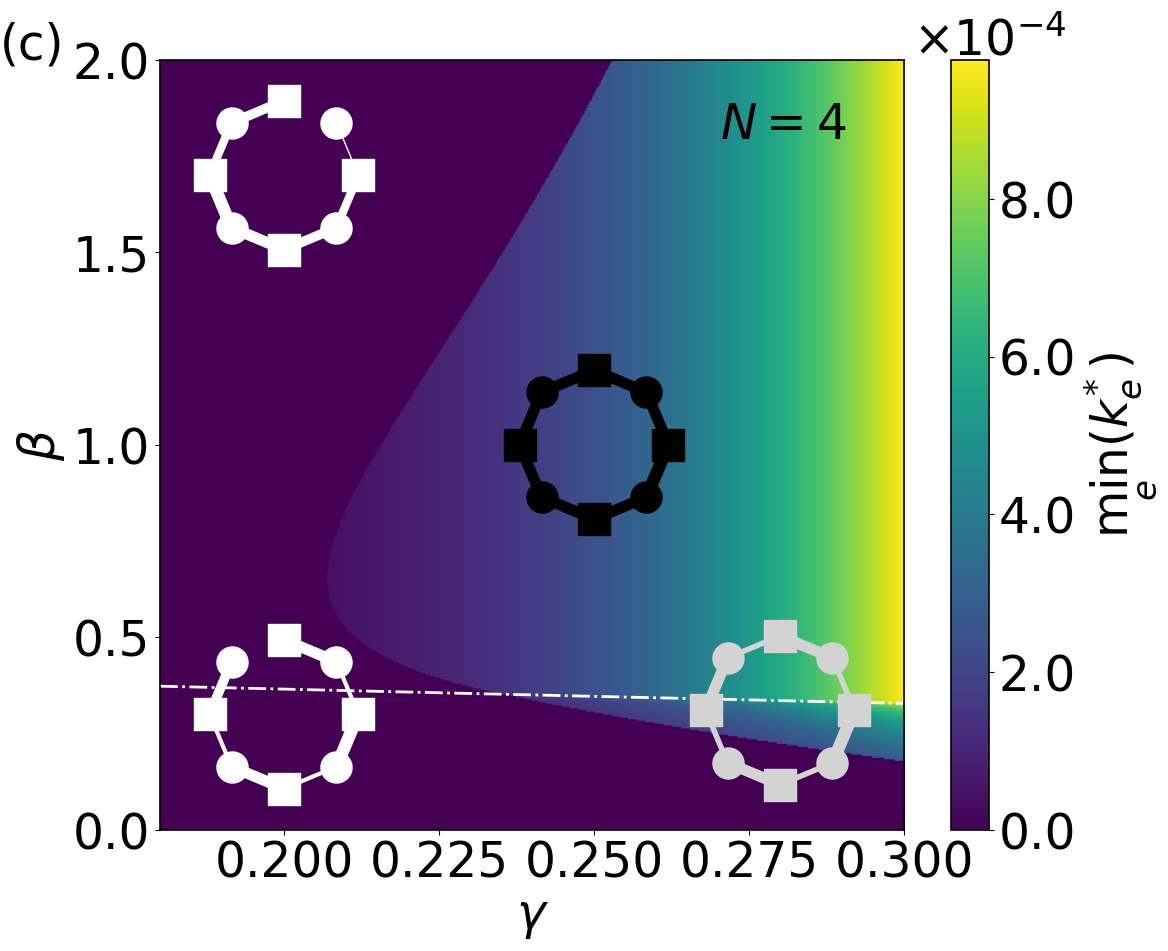

In [24]:
#gamma, beta, color
insets = [(0.2, 0.3, "white"), (0.2, 1.7, "white"), (0.25, 1.0, "black"), (0.28, 0.31, "lightgray")]

fig, ax = plot_phase_with_insets(N, mu, gamma_values, beta_values, capacity_values, insets, "(c)", save_final_fig=False)
factor = np.sqrt(3*mu*mu/(N*N-1))
beta_line_lower = factor*np.sqrt((1-gamma_values)/(1+gamma_values))
ax.plot(gamma_values, beta_line_lower, color="white", linewidth=2, linestyle="dashdot")
ax.set_xlim([min(gamma_values), max(gamma_values)])
ax.set_ylim([min(beta_values), max(beta_values)])
plt.savefig("Fig5_c.pdf", bbox_inches="tight")
plt.show()

(d): Optimal network state as a function of the scaling exponent $\gamma$ for $N=2$. At $\beta=0.2$, the transtion from strongly symmetry-broken to symmetric state occurs via a weakly symmetry-broken state.

(e): Optimal network state as a function of the fluctuation strength $\beta$ and $N=2$ for $\gamma=0.55$. There is a reentrant phase transition from one type of strongly symmetry-broken state to symmetric and back to another strongly symmetry-broken state, via distinct weakly symmetry-broken states.

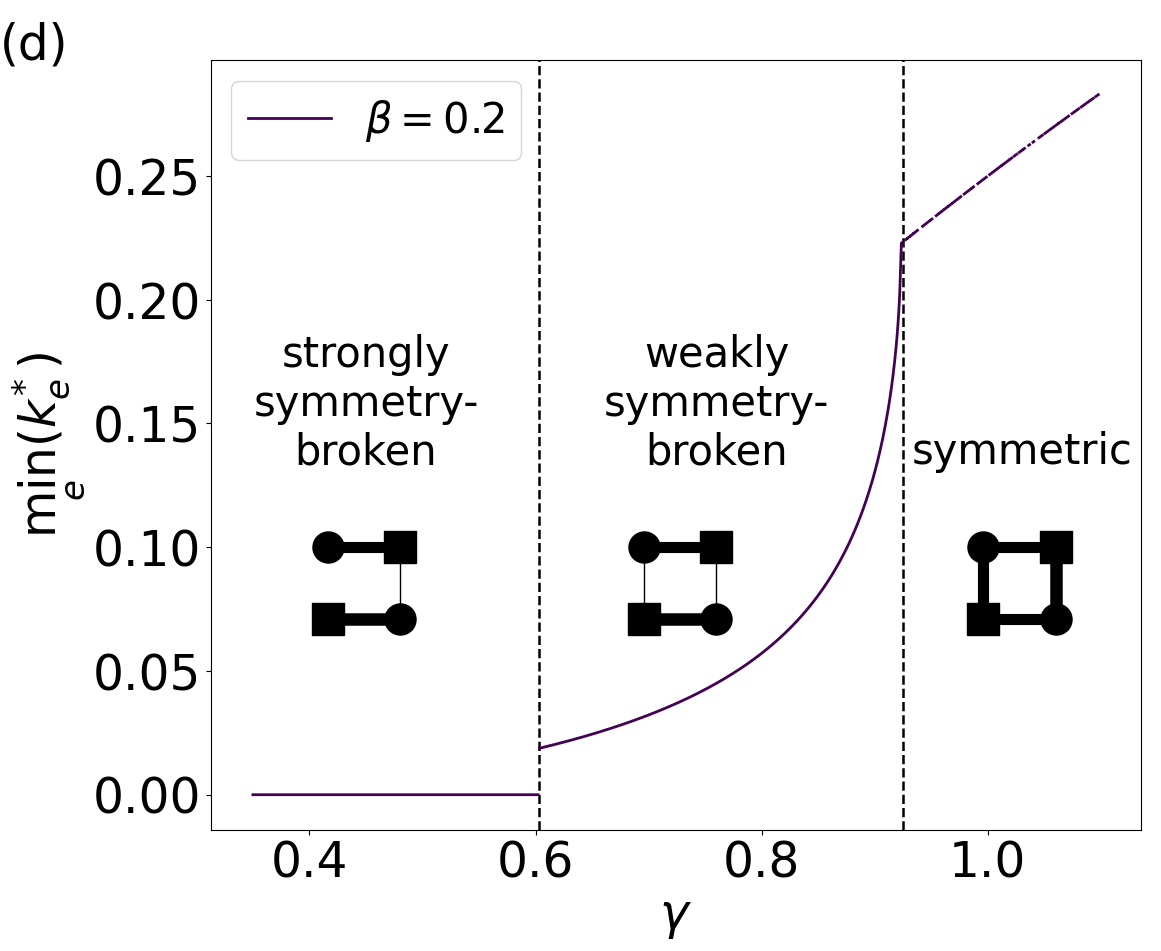

In [3]:
mu = 1.0
N = 2
kappa = 1.0

fixed_betas = [0.2]
gamma_values = np.linspace(0.35, 1.1, 1000)
minK_d, branch_labels_d = get_capacities_all_branches(N=N, mu=mu, beta_values=fixed_betas, gamma_values=gamma_values, kappa=kappa)

fig, ax, jump_positions = plot_curves_fixed_betas(fixed_betas, gamma_values, minK_d, branch_labels_d, label="(d)")

G_strong, _, _ = build_optimized_ring_graph(N, beta=0.2, gamma=0.4, mu = 1.0)
G_weak, _, _ = build_optimized_ring_graph(N, beta=0.2, gamma=0.7, mu = 1.0)
G_sym, _, _ = build_optimized_ring_graph(N, beta=0.2, gamma=1.0, mu = 1.0)

add_network_inset_xy(ax, G_strong, x=0.48, y=0.1, size=0.25, color="black")
add_network_inset_xy(ax, G_weak,   x=0.76, y=0.1, size=0.25, color="black")
add_network_inset_xy(ax, G_sym,    x=1.06, y=0.1, size=0.25, color="black")

ax.text(0.45, 0.13, "strongly\nsymmetry-\nbroken", ha="center", va="bottom", fontsize=30)
ax.text(0.76, 0.13, "weakly\nsymmetry-\nbroken", ha="center", va="bottom", fontsize=30)
ax.text(1.03, 0.13, "symmetric", ha="center", va="bottom", fontsize=30)
#plt.savefig("Fig5_d.pdf", bbox_inches="tight")
plt.show()

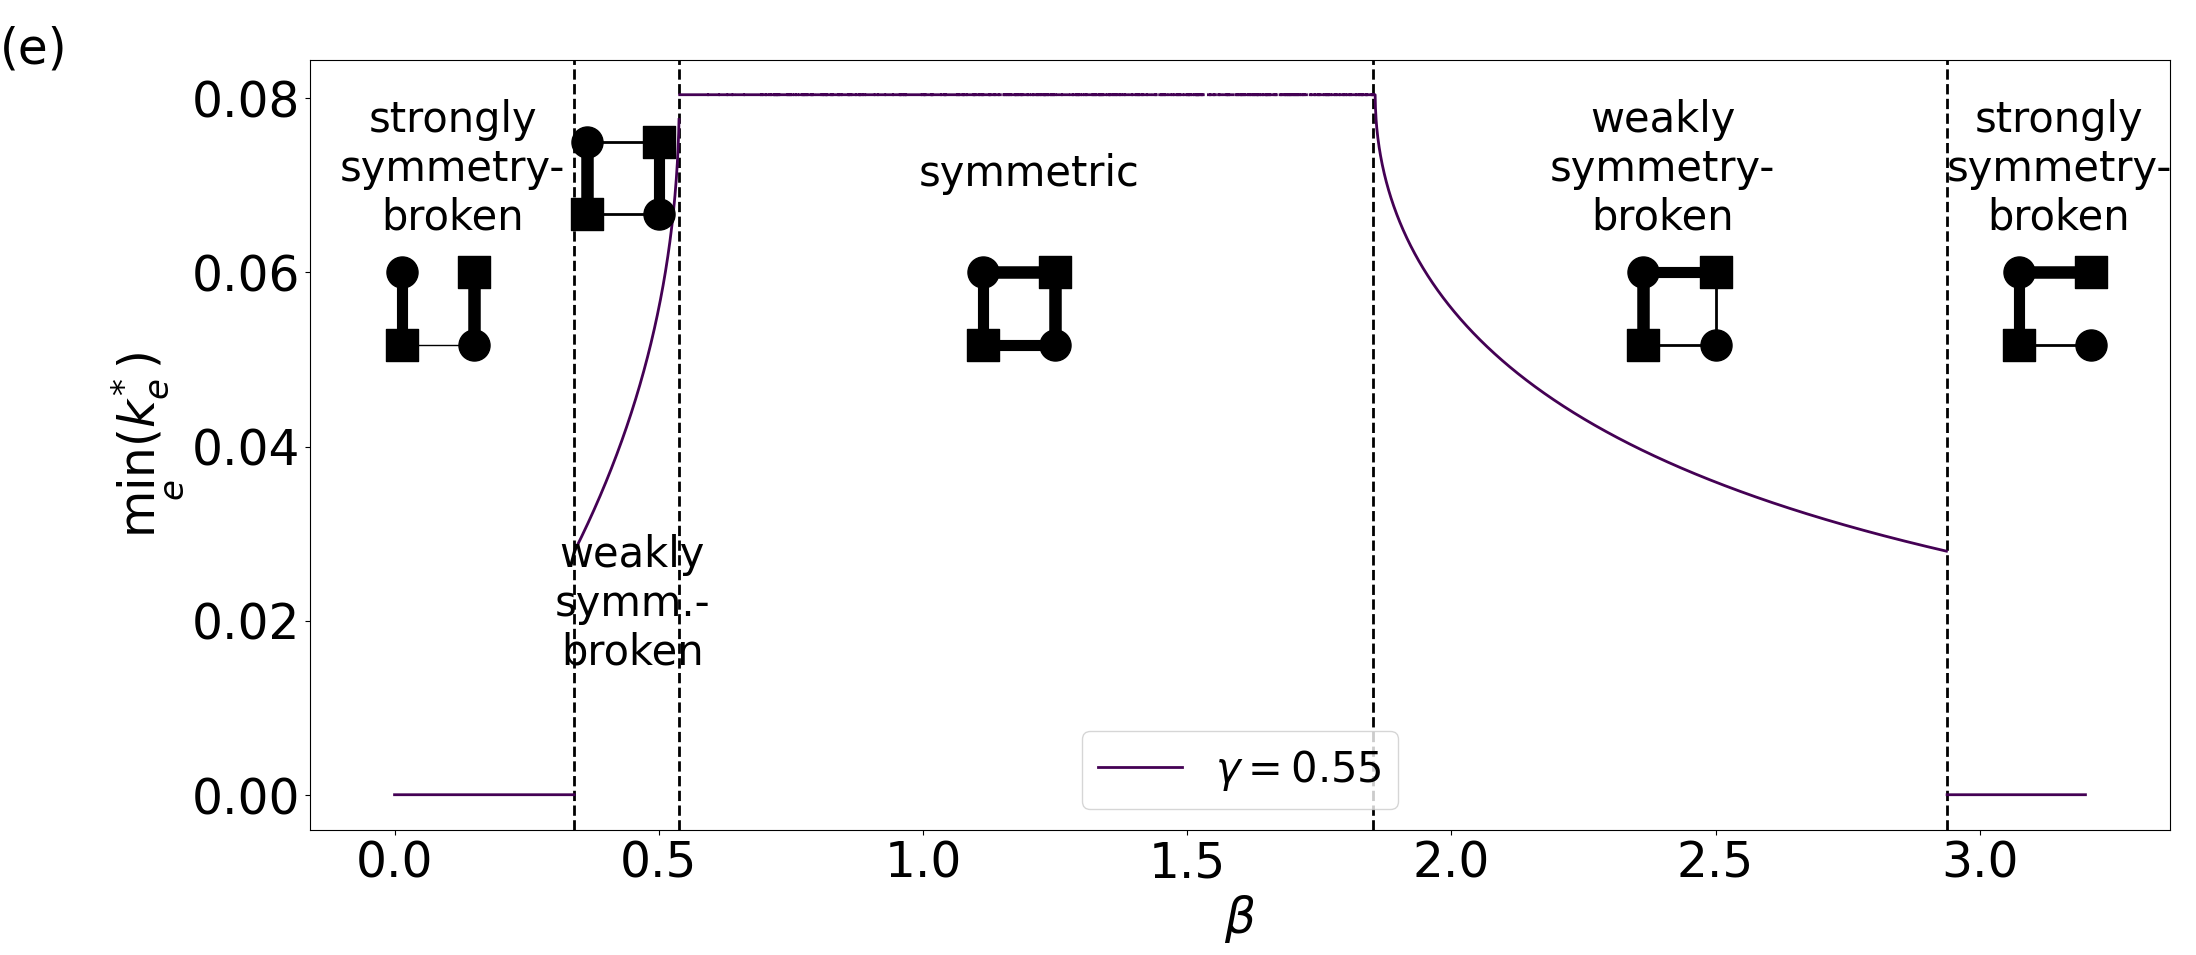

In [4]:
mu = 1.0
N = 2
kappa = 1.0

fixed_gammas = [0.55]
beta_values = np.linspace(0., 3.2, 5000)
minK_e, branch_labels_e = get_capacities_all_branches(N=N, mu=mu, beta_values=beta_values, gamma_values=fixed_gammas, kappa=kappa)


G_strong1, _, _ = build_optimized_ring_graph(N, beta=0.1, gamma=0.55, mu = 1.0)
G_weak1, _, _ = build_optimized_ring_graph(N, beta=0.35, gamma=0.55, mu = 1.0)
G_sym, _, _ = build_optimized_ring_graph(N, beta=1.0, gamma=0.55, mu = 1.0)
G_weak2, _, _ = build_optimized_ring_graph(N, beta=2.8, gamma=0.55, mu = 1.0)
G_strong2, _, _ = build_optimized_ring_graph(N, beta=3.0, gamma=0.55, mu = 1.0)

fig, ax = plot_curves_fixed_gammas(beta_values, fixed_gammas, minK_e, branch_labels_e, label = "(e)")

add_network_inset_xy(ax, G_strong1, x=0.15, y=0.06, size=0.25, color="black")
add_network_inset_xy(ax, G_weak1,   x=0.5, y=0.075, size=0.25, color="black")
add_network_inset_xy(ax, G_sym,     x=1.25, y=0.06, size=0.25, color="black")
add_network_inset_xy(ax, G_weak2,   x=2.50, y=0.06, size=0.25, color="black")
add_network_inset_xy(ax, G_strong2, x=3.21, y=0.06, size=0.25, color="black")

ax.text(0.11, 0.065, "strongly\nsymmetry-\nbroken", ha="center", fontsize=30)
ax.text(0.45, 0.015, "weakly\nsymm.-\nbroken", ha="center", fontsize=30)
ax.text(1.20, 0.07, "symmetric", ha="center", fontsize=30)
ax.text(2.40, 0.065, "weakly\nsymmetry-\nbroken", ha="center", fontsize=30)
ax.text(3.15, 0.065, "strongly\nsymmetry-\nbroken", ha="center", fontsize=30)
#plt.savefig("Fig5_e.pdf", bbox_inches="tight")
plt.show()

# Figure 6

(a) Scaling behavior of the expected dissipation in the symmetry-broken state $\bar D_a$ and the symmetric state $\bar D_s$ with the fluctuation strength $\beta$, shown for $\mu=1$, $N=2$ and $\gamma=0.53$.

In [13]:
# Define parameters
N = 2
mu = 1.0
kappa = 1.0
gamma = 0.53
beta_values = np.logspace(-5, np.log10(6.0), 1000)

# Calculate symmetric and asymmetric dissipation and capacities
D_s = np.empty_like(beta_values, dtype=float)
D_a = np.empty_like(beta_values, dtype=float)

k_sym = k_symmetric(N, gamma, kappa=kappa) # Symmetric capacities do not depend on beta

for i, beta in enumerate(beta_values): # Symmetry broken capacities depend on beta
    Sigma = compute_ring_second_moment_matrix(mu, beta, N)

    D_s[i] = expected_dissipation_ring(N, k_sym, Sigma)
    D_a[i], _ = compute_asymmetric_case_from_sigma(N, gamma, Sigma, kappa=kappa, broken_edge=-1)

# Large-beta scaling fit
large_beta_mask = beta_values > 2
beta_fit = beta_values[large_beta_mask]

scaling_Ds, intercept_Ds = np.polyfit(np.log(beta_fit), np.log(D_s[large_beta_mask]), 1)
scaling_Da, intercept_Da = np.polyfit(np.log(beta_fit), np.log(D_a[large_beta_mask]), 1)

Ds_fit = np.exp(intercept_Ds) * beta_fit**scaling_Ds
Da_fit = np.exp(intercept_Da) * beta_fit**scaling_Da

# Small beta -> 0 value
small_beta_fit_mask = beta_values < 0.005
Ds_limit = D_s[small_beta_fit_mask].mean()
Da_limit = D_a[small_beta_fit_mask].mean()

print("Scaling for large beta:")
print(f"  $D_s ~ beta^{{{scaling_Ds:.2f}}}$")
print(f"  D_a ~ beta^{scaling_Da:.2f}")
print("\nLimiting values for small beta:")
print(f"  D_s(beta->0) ~ {Ds_limit:.4f}")
print(f"  D_a(beta->0) ~ {Da_limit:.4f}")

Scaling for large beta:
  $D_s ~ beta^{1.83}$
  D_a ~ beta^1.58

Limiting values for small beta:
  D_s(beta->0) ~ 13.6761
  D_a(beta->0) ~ 7.4588


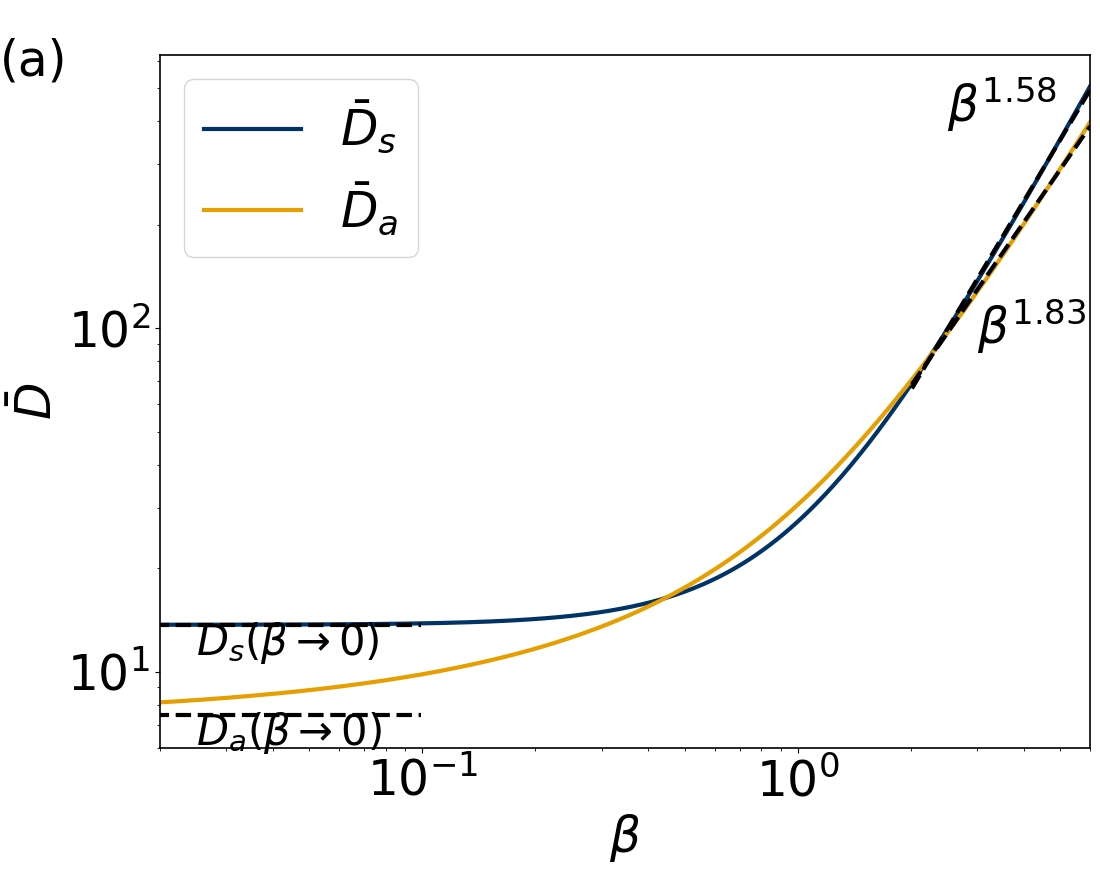

In [14]:
fig, ax = plt.subplots(figsize=(12, 9))

ax.plot(beta_values, D_s, lw=3, label=r'$\bar D_s$', color="#003366")
ax.plot(beta_values, D_a, lw=3, label=r'$\bar D_a$', color="#E69F00")

# Large beta: fitted power-law lines
ax.plot(beta_fit, Ds_fit, '--', color="k", lw = 3)
ax.plot(beta_fit, Da_fit, '--', color="k", lw = 3)
ax.text(3., 90, rf'$\beta^{{{scaling_Ds:.2f}}}$', color='k', fontsize=35)
ax.text(2.5, 400, rf'$\beta^{{{scaling_Da:.2f}}}$', color='k', fontsize=35)

# Small beta: asymptotes plotted on a larger visible beta range than what was used to calculate them
small_beta_plot_mask = beta_values < 0.1
beta_small_plot = beta_values[small_beta_plot_mask]

ax.plot(beta_small_plot, np.full_like(beta_small_plot, Ds_limit), '--', color='k', linewidth=3)
ax.plot(beta_small_plot, np.full_like(beta_small_plot, Da_limit), '--', color='k', linewidth=3)

ax.text(0.025, Ds_limit * 0.82, r'$D_s(\beta\to0)$', color='k', fontsize=30)
ax.text(0.025, Da_limit * 0.82, r'$D_a(\beta\to0)$', color='k', fontsize=30)

ax.set_xlim(0.02, beta_values.max())

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\beta$', fontsize=35)
ax.set_ylabel(r'$\bar D$', fontsize=35)
ax.tick_params(axis='both', labelsize=35)
ax.legend(loc='best', fontsize=35)

ax.annotate("(a)", xy=(0.0, 0.93), xycoords='figure fraction', fontsize=35, color='black', ha='left', va='top')
# plt.savefig("Fig_scaling_a.pdf", bbox_inches='tight') 
plt.show()

(b) Scaling with system size $N$ of the minimal value $\gamma_c$ for which we observe the phase transition between symmetry-broken and symmetric states, for $\mu=1$.

In [15]:
# Define parameters
N_values = np.arange(2, 10, 1)
mu = 1.0
kappa = 1.0

gamma_approx = [0.440591, 0.28053, 0.20590, 0.16269, 0.13323, 0.11261, 0.09690, 0.084138]  # N=2..9
cusp_betas_approx = [0.98465, 0.77011, 0.642957, 0.549984, 0.5010219, 0.4229199, 0.409576, 0.36420726]

# Calculate gamma_c
gamma_c = gamma_c_vs_N(N_values, mu, gamma_approx, cusp_betas_approx)
np.save("gamma_c_vs_N.npy", gamma_c)

# Later load with
# gamma_c = np.load("gamma_c_vs_N.npy")

Calculating N=2 on gamma in [0.4186,0.4626] beta in [0.9354,1.034]
Calculating N=3 on gamma in [0.2665,0.2946] beta in [0.7316,0.8086]
Calculating N=4 on gamma in [0.1956,0.2162] beta in [0.6108,0.6751]
Calculating N=5 on gamma in [0.1546,0.1708] beta in [0.5225,0.5775]
Calculating N=6 on gamma in [0.1266,0.1399] beta in [0.476,0.5261]
Calculating N=7 on gamma in [0.107,0.1182] beta in [0.4018,0.4441]
Calculating N=8 on gamma in [0.08236,0.1114] beta in [0.3277,0.4915]
Calculating N=9 on gamma in [0.07152,0.09676] beta in [0.2914,0.437]


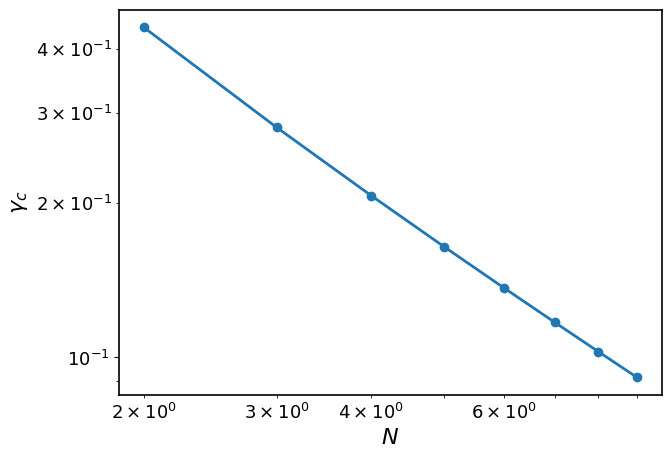

In [16]:
# Preview results
fig, ax = plt.subplots(figsize=(7,5))
ax.loglog(N_values, gamma_c, marker='o', lw=2)
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$\gamma_c$")
plt.show()

In [17]:
k_cusp_theory = [1 / (2 * N_values[i]) ** (1 / gamma_c[i]) for i in range(len(N_values))]

def k_crit_function(N, c, alpha):
    return (2*N)**(-N**alpha/c)

def power_law(N, c, alpha):
    return c * N**(-alpha)

# Fit the data
popt, pcov = curve_fit(power_law, N_values, gamma_c)
c_fit, alpha_fit = popt
c_err, alpha_err = np.sqrt(np.diag(pcov)) # uncertainty on parameters

print(f"Fitted parameters: c = {c_fit:.3f} ± {c_err:.3f}, alpha = {alpha_fit:.3f} ± {alpha_err:.3f}")

Fitted parameters: c = 0.915 ± 0.010, alpha = 1.063 ± 0.010


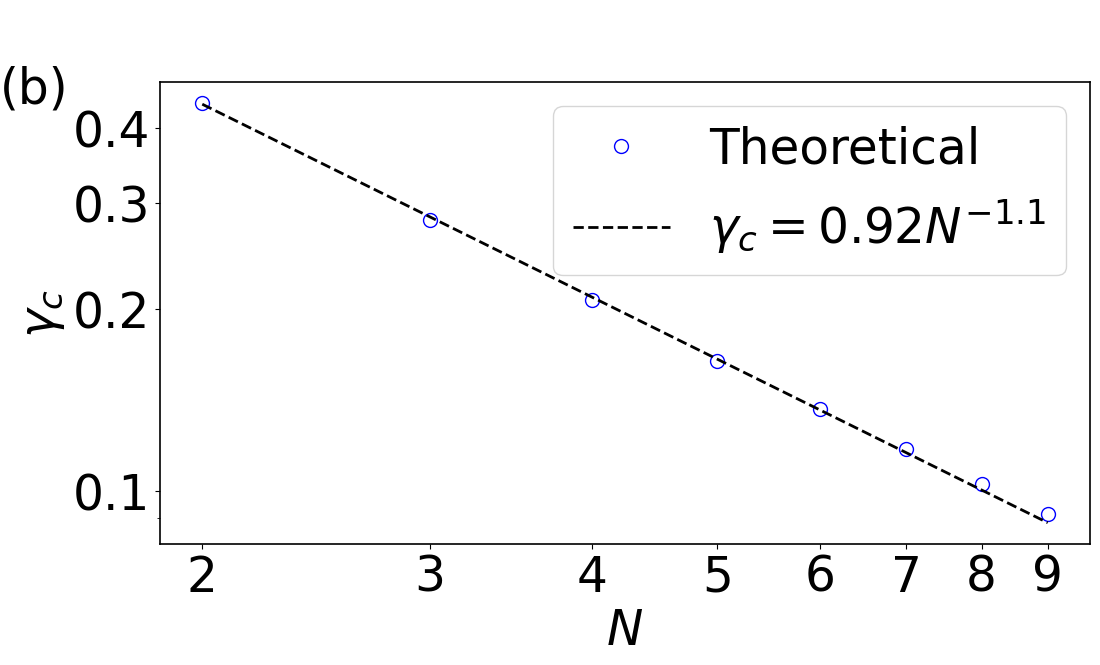

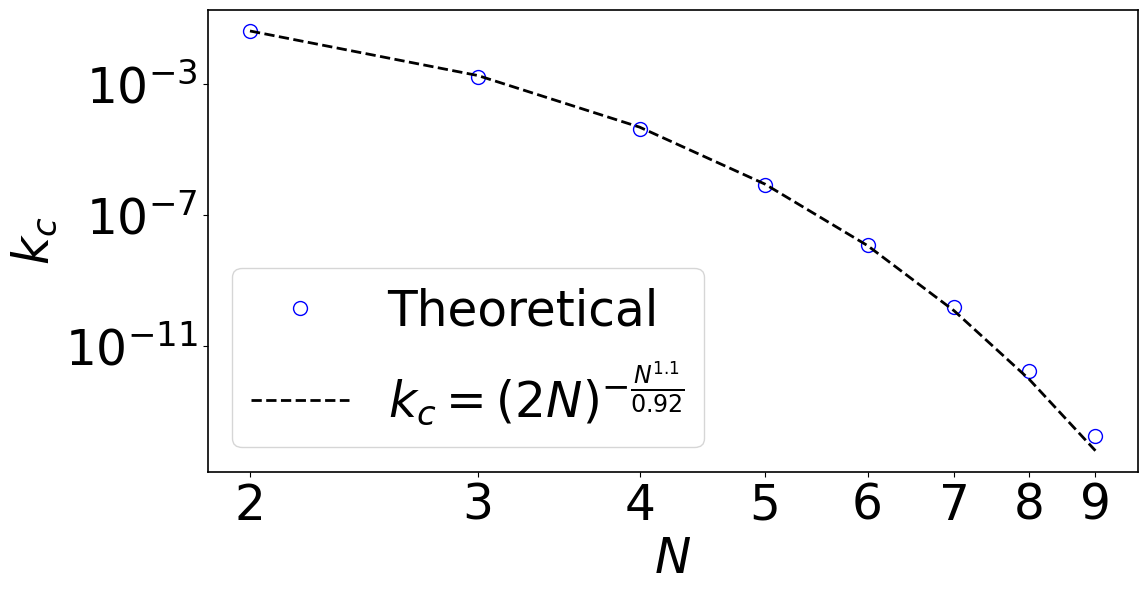

In [18]:
# Plot Figure 6b
xticks = N_values 
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
# First subplot
ax.loglog(N_values[:9], gamma_c[:9], 'bo', mfc='none', markersize = 10, label='Theoretical')
ax.loglog(N_values[:9], power_law(N_values[:9], *popt), 'k--', label= r'$\gamma_c = $'+ f'${c_fit:.2f} N^{{{-alpha_fit:.1f}}}$')
ax.set_ylabel(r'$\gamma_c$', fontsize=35)
yticks1 = [0.1, 0.2, 0.3, 0.4]
ax.set_yticks(yticks1)  
ax.set_xticks(N_values[:9])  
ax.set_yticklabels([str(x) for x in yticks1])
ax.set_xticklabels([str(x) for x in N_values[:9]])
ax.set_xlabel(r'$N$', fontsize=35)
ax.legend(fontsize=35)
ax.tick_params(axis='both', which='major', labelsize=35)
ax.annotate("(b)", xy=(0.0, 1.0), xycoords='figure fraction', fontsize=35, color='black', ha='left', va='top')
#plt.savefig("Fig_scaling_b.pdf", bbox_inches='tight') 
plt.show()

# Plot Figure 11 (in Appendix)
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.loglog(N_values[:9], k_cusp_theory[:9], 'bo', mfc='none', markersize = 10, label='Theoretical')
ax.loglog(N_values[:9], k_crit_function(N_values, *popt), 'k--', label = f'$k_c = (2N)^{{-\\frac{{N^{{{alpha_fit:.1f}}}}}{{{c_fit:.2f}}}}}$')
ax.set_xlabel(r'$N$', fontsize=35)
ax.set_ylabel(r'$k_c$', fontsize=35)
ax.set_xticks(N_values[:9])  
ax.set_xticklabels([str(x) for x in N_values[:9]])
ax.legend(fontsize=35)
ax.tick_params(axis='both', which='major', labelsize=35)
#plt.savefig("Fig_scaling_supplement.pdf", bbox_inches='tight') 
plt.show()

# Figure 10

Perturbation $\varepsilon_*$ at which $\bar D(\varepsilon)-\bar D(0)$ changes sign as a function of $\gamma$. Numerical results (solid line) agree with the asymptotic prediction (dashed line). The rapid decrease of $\varepsilon_*$ as $\gamma \to 1^{-}$ shows that the symmetry-broken state remains locally stable for all $\gamma<1$, but becomes increasingly difficult to calculate numerically.

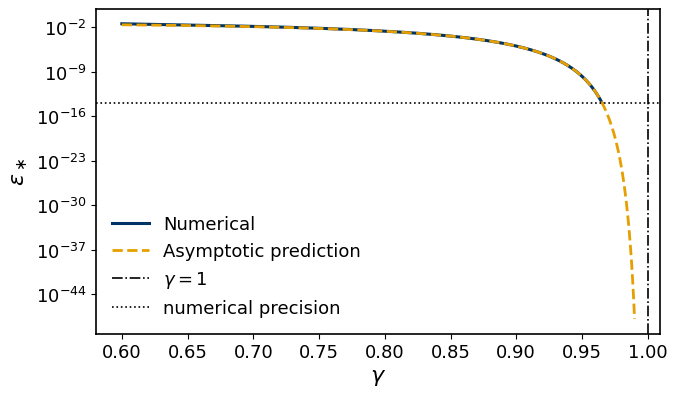

In [25]:
mpl.rcParams.update({"font.size": 14, "axes.labelsize": 16, "axes.titlesize": 16, "legend.fontsize": 13,
                    "xtick.labelsize": 13, "ytick.labelsize": 13})
mpl.rcParams["axes.linewidth"] = 1.2
mpl.rcParams["lines.linewidth"] = 2

beta = 1.0

# Epsilon grid for detecting the sign change
eps_vals = np.logspace(-14, -0.5, 2500)

# Gamma range below 1
gamma_scan = np.linspace(0.6, 0.99, 500)
#eps_cross_num = []

# Numerical precision limit
numerical_precision = 1e-14

# Calculate values
gamma_numerical, eps_numerical, gamma_asymptotic, eps_asymptotic = get_Figure10_data(gamma_scan, eps_vals, beta = beta, kappa = 1.0, numerical_precision = numerical_precision)

# Plot them
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(gamma_numerical, eps_numerical, linewidth=2.2,color="#003366",  label="Numerical")
ax.plot(gamma_asymptotic, eps_asymptotic, linestyle="--", color="#E69F00", linewidth=2.0, label="Asymptotic prediction")
ax.set_yscale("log")
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\varepsilon_\ast$")
ax.axvline(1.0, linestyle="dashdot", color = 'k', linewidth=1.2, label = r"$\gamma=1$")
ax.axhline(numerical_precision, linestyle=":", color = 'k', linewidth=1.2, label = "numerical precision")
ax.legend(frameon=False)
fig.tight_layout()
#plt.savefig(f"eps_star.pdf", bbox_inches="tight")
plt.show()
